In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
!pip install torch torchvision torchaudio


[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [3]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_vanishing_gradient



Without Skip Connections:

Gradients for selected layers:
Layer 1 Gradient:
\begin{pmatrix}
-1.62 \\
-1.53 \\
2.28
\end{pmatrix} \times 10^{-9}

Layer 2 Gradient:
\begin{pmatrix}
-2.98 & -3.15 & -3.03 \\
5.10 & 5.39 & 5.18 \\
-3.94 & -4.16 & -4.00
\end{pmatrix} \times 10^{-9}

Layer 3 Gradient:
\begin{pmatrix}
2.35 & 3.37 & 4.63 \\
0.83 & 1.19 & 1.63 \\
1.59 & 2.27 & 3.12
\end{pmatrix} \times 10^{-8}

Layer 10 Gradient:
\begin{pmatrix}
0.75 & 0.57 & 1.17 \\
1.43 & 1.08 & 2.22 \\
2.32 & 1.76 & 3.61
\end{pmatrix} \times 10^{-2}



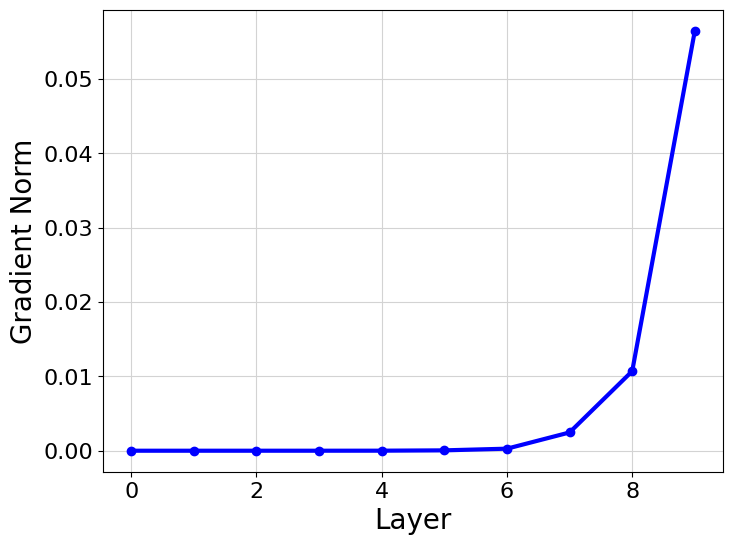


With Skip Connections:

Gradients for selected layers:
Layer 1 Gradient:
\begin{pmatrix}
-1.06 \\
2.33 \\
0.91
\end{pmatrix} \times 10^{-1}

Layer 2 Gradient:
\begin{pmatrix}
-1.19 & -1.48 & -1.14 \\
2.74 & 3.39 & 2.61 \\
1.87 & 2.31 & 1.78
\end{pmatrix} \times 10^{-1}

Layer 3 Gradient:
\begin{pmatrix}
-0.54 & -0.71 & -0.67 \\
0.88 & 1.17 & 1.10 \\
2.79 & 3.69 & 3.49
\end{pmatrix} \times 10^{-1}

Layer 10 Gradient:
\begin{pmatrix}
-0.62 & -0.37 & -0.61 \\
7.03 & 4.24 & 6.98 \\
4.26 & 2.57 & 4.23
\end{pmatrix} \times 10^{-1}



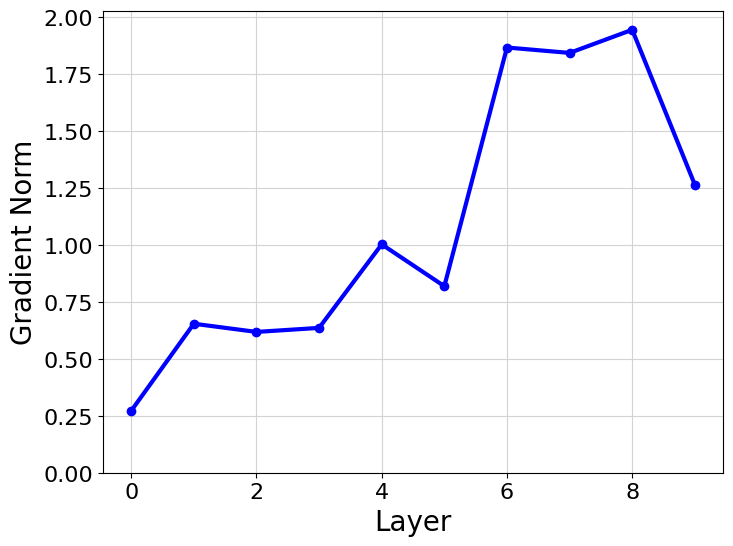

In [13]:
# Import necessary libraries
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from collections import Counter

# Define the deep neural network with an option for skip connections
class DeepNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, use_skip=False):
        super(DeepNet, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.use_skip = use_skip
        
        # Create a sequence of fully connected layers
        self.layers = nn.ModuleList()
        self.activations = nn.ModuleList()
        
        # First layer
        self.layers.append(nn.Linear(input_size, hidden_size))
        self.activations.append(nn.Sigmoid())
        
        # Hidden layers
        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_size, hidden_size))
            self.activations.append(nn.Sigmoid())
        
        # Output layer
        self.output_layer = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Forward pass with or without skip connections
        for i in range(self.num_layers):
            skip = x if self.use_skip else 0
            x = self.layers[i](x)
            x = self.activations[i](x)
            x = x + skip  # Using out-of-place addition for skip connection
        
        # Output layer
        x = self.output_layer(x)
        return x

# Function to format values into a matrix with a common power of 10
def format_matrix_with_common_power(grad):
    # Convert gradient values to scientific notation
    flattened_grad = grad.view(-1).numpy()  # Convert tensor to numpy array
    nonzero_grad = flattened_grad[flattened_grad != 0]  # Remove zero values to avoid log issues
    
    if len(nonzero_grad) == 0:
        # All gradient values are zero, handle this case separately
        return "\\begin{pmatrix} 0 & 0 & 0 \\end{pmatrix}", 0

    exponents = np.floor(np.log10(np.abs(nonzero_grad))).astype(int)
    most_common_exponent = Counter(exponents).most_common(1)[0][0]

    # Scale values to match the most common exponent
    scaled_values = flattened_grad / (10. ** most_common_exponent)
    
    # Format the matrix for LaTeX
    matrix_rows = []
    for row in grad:
        row_values = [
            "0" if val.item() == 0 else f"{val.item() / (10. ** most_common_exponent):.2f}" 
            for val in row
        ]
        matrix_rows.append(" & ".join(row_values))
    
    matrix_latex = "\\begin{pmatrix}\n" + " \\\\\n".join(matrix_rows) + "\n\\end{pmatrix}"
    return matrix_latex, most_common_exponent

# Define a function to calculate and print gradients with the most common power of 10
def calculate_and_print_gradients(model, loss_fn, input_data, target, output_path):
    # Forward pass
    output = model(input_data)
    loss = loss_fn(output, target)
    
    # Backward pass
    model.zero_grad()
    loss.backward()
    
    # Print gradients for selected layers (first 3 and last layer)
    print("\nGradients for selected layers:")
    selected_layers = [0, 1, 2, len(model.layers) - 1]  # Select first 3 layers and the last layer

    for i in selected_layers:
        grad = model.layers[i].weight.grad
        matrix_latex, common_exponent = format_matrix_with_common_power(grad)
        print(f"Layer {i + 1} Gradient:")
        print(f"{matrix_latex} \\times 10^{{{common_exponent}}}")
        print()  # Blank line between layers for readability

    # Optionally plot the gradient norms if needed
    gradient_norms = [model.layers[i].weight.grad.norm().item() for i in range(len(model.layers))]
    plt.figure(figsize=(8, 6))
    plt.plot(range(len(gradient_norms)), gradient_norms, marker='o', linestyle='-', color='#0000FF', linewidth=3)
    plt.xlabel("Layer", fontsize=20)
    plt.ylabel("Gradient Norm", fontsize=20)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(True, color='#D3D3D3')

    if model.use_skip:
        plt.ylim(bottom=0)

    output_path = Path(output_path) / ("vanishing_gradient_with_skip.png" if model.use_skip else "vanishing_gradient_without_skip.png")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

# Set up the problem with the new parameter settings
input_size = 1      # Number of input features
hidden_size = 3     # Number of neurons in each hidden layer (narrow network)
num_layers = 10     # Number of hidden layers (deep network)
output_size = 1     # Number of output features

# Create random input and target data
torch.manual_seed(0)  # Ensure reproducibility
input_data = torch.randn((1, input_size))
target = torch.randn((1, output_size))

# Instantiate the network with and without skip connections
use_skip = True

# Without skip connections
print("\nWithout Skip Connections:")
model_without_skip = DeepNet(input_size, hidden_size, num_layers, output_size, use_skip=False)
loss_fn = nn.MSELoss()
calculate_and_print_gradients(model_without_skip, loss_fn, input_data, target, OUTPUT_DIR)

# With skip connections
print("\nWith Skip Connections:")
model_with_skip = DeepNet(input_size, hidden_size, num_layers, output_size, use_skip=True)
calculate_and_print_gradients(model_with_skip, loss_fn, input_data, target, OUTPUT_DIR)